## Correlating the empirical and predicted repetition matrix

In this script we will correlate for each subject their empirical repetition matrix with the repetition matrix generated from predicted data based on the parameter estimates of the vanilla DDM, across-trial variability DDM, and the autocorrelated DDM.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, ttest_rel
import pingouin as pg

### Import data and calculate correlations

In [2]:
datasets = ["Adler_2018_Expt1_taskA", "Adler_2018_Expt1_taskB", "Adler_2018_Expt3", "Desender_2022_exp2B",
           "Law_unpub", "Maniscalco_2017_expt2", "Shekhar_2021", "Zang_2026"]

In [3]:
correlation_repetition_matrix = []

empirical_repetition_all_datasets = []
simulated_repetition_vanilla_all_datasets = []
simulated_repetition_variability_all_datasets = []
simulated_repetition_autocorrelated_all_datasets = []


for dataset in datasets:
    
    # Import repetition matrices
    empirical_repetition = pd.read_csv(f"/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/3. Autocorrelated DDM/Data/{dataset}_autocorrelated_ddm_empirical_repetition_matrix_subject.csv")

    simulated_repetition_vanilla = pd.read_csv(f"/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/1. Vanilla DDM/Data/{dataset}_vanilla_ddm_predicted_repetition_matrix_subject.csv")
    simulated_repetition_variability = pd.read_csv(f"/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/2. Across-trial variability DDM/Data/{dataset}_across_trial_variability_ddm_predicted_repetition_matrix_subject.csv")
    simulated_repetition_autocorrelated = pd.read_csv(f"/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/3. Autocorrelated DDM/Data/{dataset}_autocorrelated_ddm_predicted_repetition_matrix_subject.csv")

    # Add dataset_subject
    for df in [
    empirical_repetition,
    simulated_repetition_vanilla,
    simulated_repetition_variability,
    simulated_repetition_autocorrelated]:
        df["dataset_subject"] = dataset + "_" + df["subj"].astype(str)

    # Save all of them in one dataset (for plotting later)
    empirical_repetition_all_datasets.append(empirical_repetition)
    simulated_repetition_vanilla_all_datasets.append(simulated_repetition_vanilla)
    simulated_repetition_variability_all_datasets.append(simulated_repetition_variability)
    simulated_repetition_autocorrelated_all_datasets.append(simulated_repetition_autocorrelated)

    # Get number of subjects
    unique_ids, counts = np.unique(empirical_repetition['subj'], return_counts=True)
    num_subjects = len(unique_ids)

    # Correlate empirical and predicted repetition matrices
    correlation_vanilla = []
    correlation_variability = []
    correlation_autocorrelated = []
    
    for subj in range(num_subjects):
        r_vanilla, _        = pearsonr(empirical_repetition['cond_prop'][empirical_repetition["subj"] == subj],
                                        simulated_repetition_vanilla['cond_prop'][simulated_repetition_vanilla["subj"] == subj])
        r_variability, _    = pearsonr(empirical_repetition['cond_prop'][empirical_repetition["subj"] == subj],
                                        simulated_repetition_variability['cond_prop'][simulated_repetition_variability["subj"] == subj])
        r_autocorrelated, _ = pearsonr(empirical_repetition['cond_prop'][empirical_repetition["subj"] == subj],
                                        simulated_repetition_autocorrelated['cond_prop'][simulated_repetition_autocorrelated["subj"] == subj])
        correlation_vanilla.append(r_vanilla)
        correlation_variability.append(r_variability)
        correlation_autocorrelated.append(r_autocorrelated)

    correlation_long = (correlation_vanilla + correlation_variability + correlation_autocorrelated)    
    subject = np.tile(np.arange(num_subjects), 3)
    
    df_long = pd.DataFrame({
        'dataset': dataset,
        'subject': subject,
        'dataset_subject': dataset + "_" + subject.astype(str),
        'correlation': correlation_long,
        'model': np.repeat(['vanilla', 'variability', 'autocorrelated'], num_subjects)
    })

    correlation_repetition_matrix.append(df_long)

# Combine all datasets into one DataFrame
correlation_repetition_matrix = pd.concat(correlation_repetition_matrix, ignore_index=True)

empirical_repetition_all_datasets = pd.concat(empirical_repetition_all_datasets, ignore_index=True)
simulated_repetition_vanilla_all_datasets = pd.concat(simulated_repetition_vanilla_all_datasets, ignore_index=True)
simulated_repetition_variability_all_datasets = pd.concat(simulated_repetition_variability_all_datasets, ignore_index=True)
simulated_repetition_autocorrelated_all_datasets = pd.concat(simulated_repetition_autocorrelated_all_datasets, ignore_index=True)

### Save correlations

In [4]:
correlation_repetition_matrix.to_csv(
    "/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/4. Correlating repetition matrices/correlation_empirical_predicted_repetition_matrix.csv",
    index=False
)

### Plot repetition matrices over all datasets

In [10]:
fontsize_heatmap=32

#### 1. Empirical data

In [ ]:
mean_sd_subjects_empirical = (
    empirical_repetition_all_datasets.groupby(["condition", "prev_condition"])["cond_prop"]
      .agg(["mean", "std"])
      .reset_index()
)

# Put in matrix form
prop_table_mean = mean_sd_subjects_empirical.pivot(index="prev_condition", columns="condition", values="mean")
prop_table_std  = mean_sd_subjects_empirical.pivot(index="prev_condition", columns="condition", values="std")

annot = prop_table_mean.round(2).astype(str) + " ± " + (prop_table_std/np.sqrt(len(np.unique(empirical_repetition_all_datasets['subj'])))).round(2).astype(str)
condition_labels = ['Fast Left', 'Fast Right', 'Slow Left', 'Slow Right']

plt.figure(figsize=(14,14))
ax = sns.heatmap(
    prop_table_mean,
    annot=annot,
    fmt="",
    cmap="crest",
    vmin = 0.0,
    vmax = 0.5,
    #cbar_kws={'label': 'Mean proportion'},
    xticklabels=condition_labels,
    yticklabels=condition_labels,
    square=True,
    cbar=False
)


ax.tick_params(axis='x', labelsize=fontsize_heatmap)
ax.tick_params(axis='y', labelsize=fontsize_heatmap)

for text in ax.texts:
    text.set_fontsize(28)

plt.ylabel("Previous error", fontsize=fontsize_heatmap)
plt.xlabel("Current error", fontsize=fontsize_heatmap)

plt.savefig("empirical_repetition_matrix.png", dpi=300, transparent=True)

#### 2. Vanilla DDM

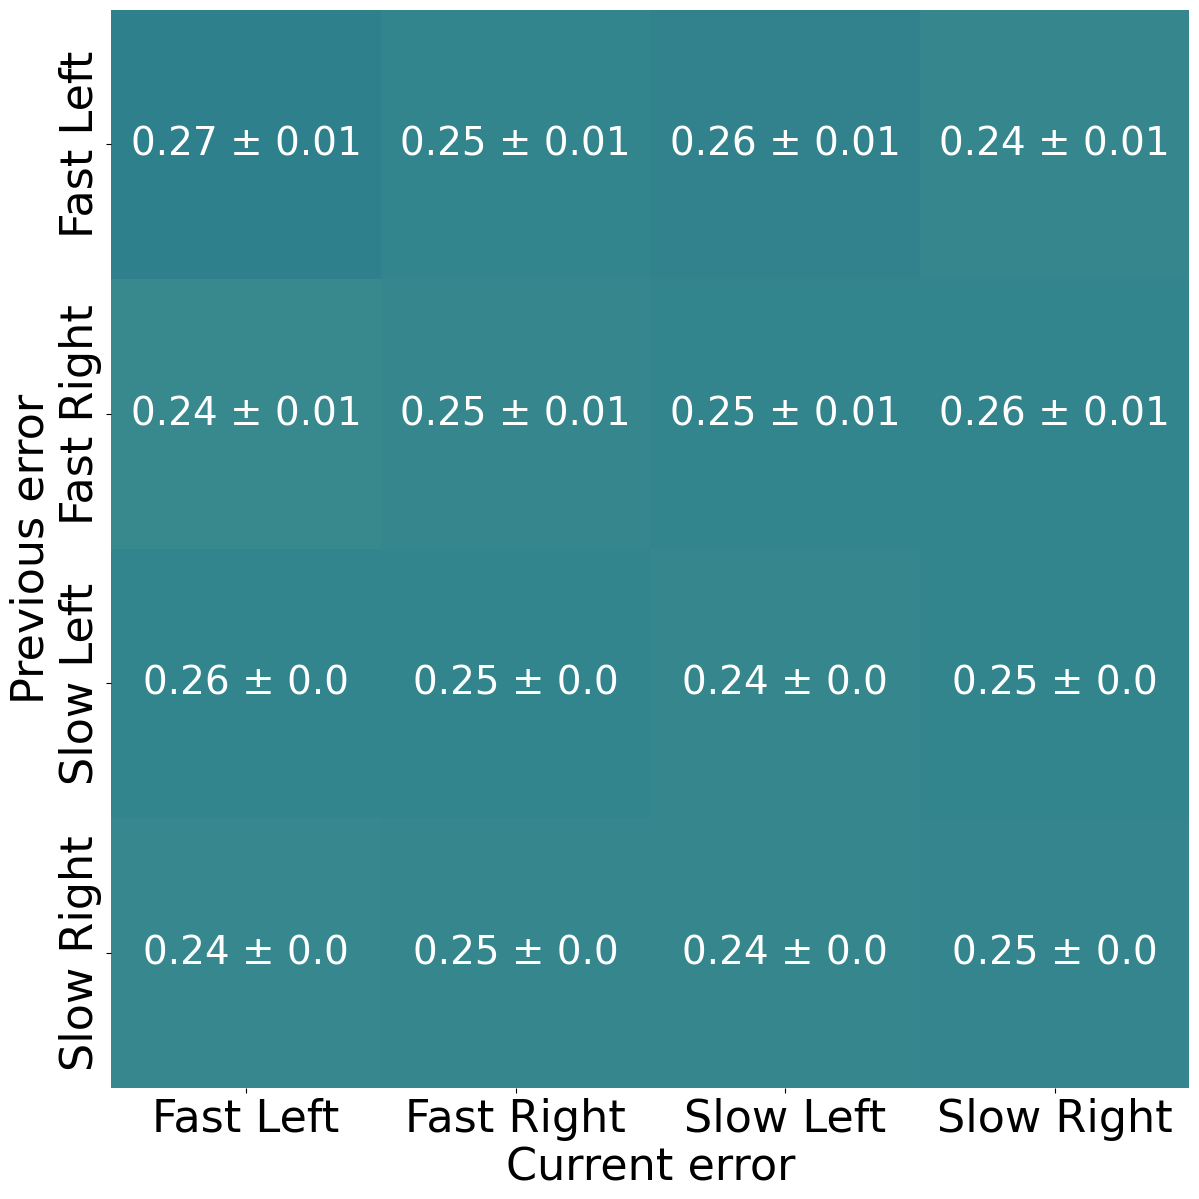

In [12]:
mean_sd_subjects_vanilla = (
    simulated_repetition_vanilla_all_datasets.groupby(["condition", "prev_condition"])["cond_prop"]
      .agg(["mean", "std"])
      .reset_index()
)

# Put in matrix form
prop_table_mean = mean_sd_subjects_vanilla.pivot(index="prev_condition", columns="condition", values="mean")
prop_table_std  = mean_sd_subjects_vanilla.pivot(index="prev_condition", columns="condition", values="std")

annot = prop_table_mean.round(2).astype(str) + " ± " + (prop_table_std/np.sqrt(len(np.unique(simulated_repetition_vanilla_all_datasets['subj'])))).round(2).astype(str)
condition_labels = ['Fast Left', 'Fast Right', 'Slow Left', 'Slow Right']

plt.figure(figsize=(14,14))
ax = sns.heatmap(
    prop_table_mean,
    annot=annot,
    fmt="",
    cmap="crest",
    vmin = 0.0,
    vmax = 0.5,
    #cbar_kws={'label': 'Mean proportion'},
    xticklabels=condition_labels,
    yticklabels=condition_labels,
    square=True,
    cbar=False
)


ax.tick_params(axis='x', labelsize=fontsize_heatmap)
ax.tick_params(axis='y', labelsize=fontsize_heatmap)

for text in ax.texts:
    text.set_fontsize(28)

plt.ylabel("Previous error", fontsize=fontsize_heatmap)
plt.xlabel("Current error", fontsize=fontsize_heatmap)

plt.savefig("vanilla_predicted_repetition_matrix.png", dpi=300, transparent=True)

#### 3. Across-trial variability DDM

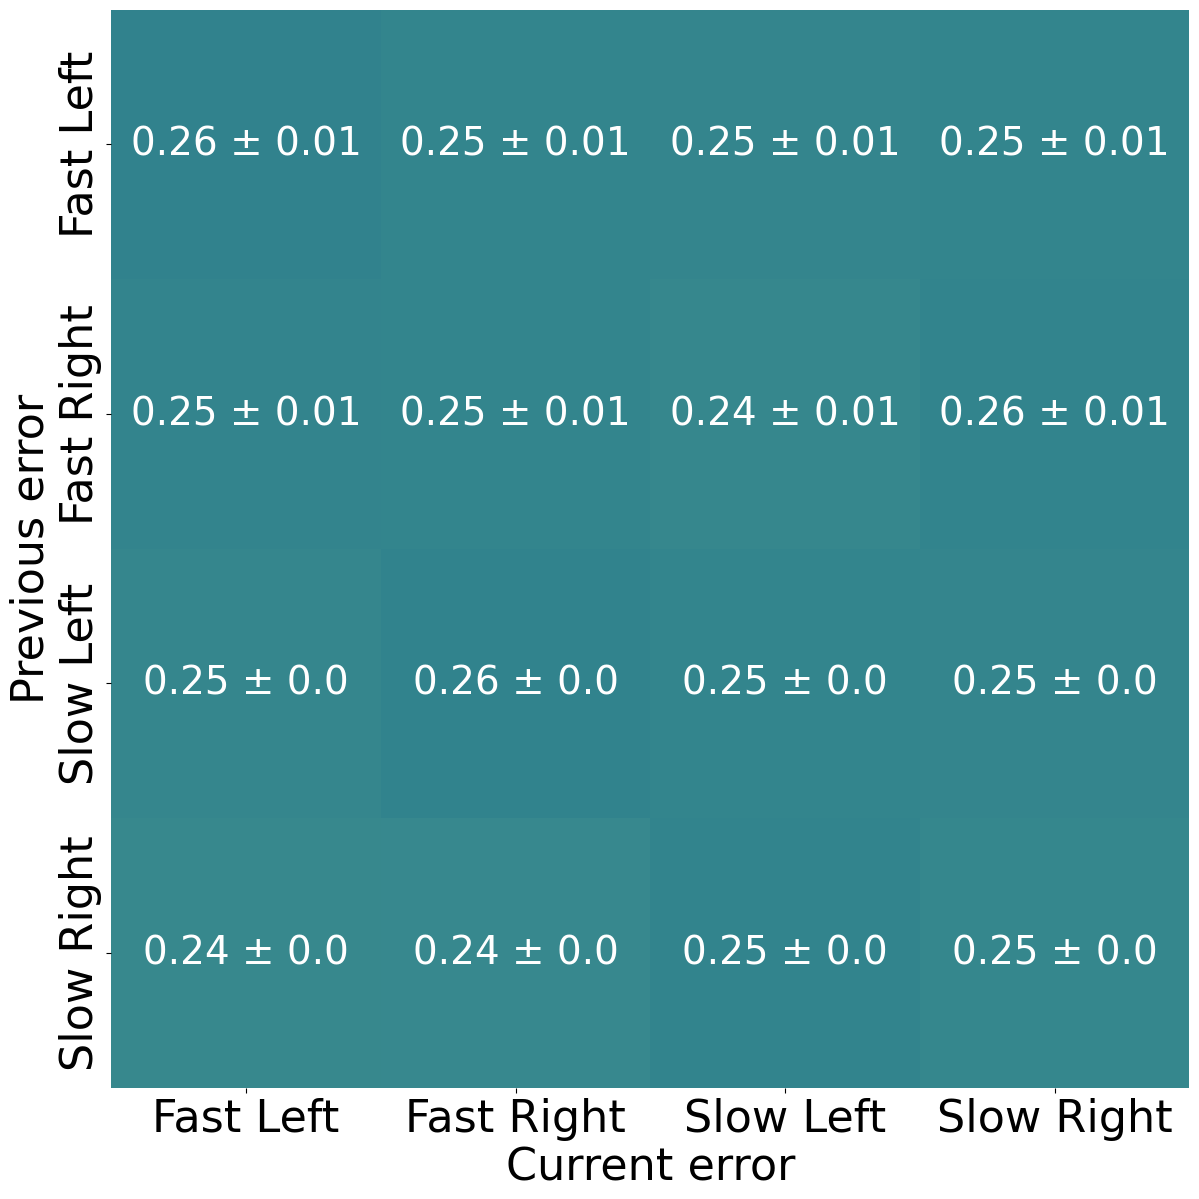

In [13]:
mean_sd_subjects_variability = (
    simulated_repetition_variability_all_datasets.groupby(["condition", "prev_condition"])["cond_prop"]
      .agg(["mean", "std"])
      .reset_index()
)

# Put in matrix form
prop_table_mean = mean_sd_subjects_variability.pivot(index="prev_condition", columns="condition", values="mean")
prop_table_std  = mean_sd_subjects_variability.pivot(index="prev_condition", columns="condition", values="std")

annot = prop_table_mean.round(2).astype(str) + " ± " + (prop_table_std/np.sqrt(len(np.unique(simulated_repetition_variability_all_datasets['subj'])))).round(2).astype(str)
condition_labels = ['Fast Left', 'Fast Right', 'Slow Left', 'Slow Right']

plt.figure(figsize=(14,14))
ax = sns.heatmap(
    prop_table_mean,
    annot=annot,
    fmt="",
    cmap="crest",
    vmin = 0.0,
    vmax = 0.5,
    #cbar_kws={'label': 'Mean proportion'},
    xticklabels=condition_labels,
    yticklabels=condition_labels,
    square=True,
    cbar=False
)


ax.tick_params(axis='x', labelsize=fontsize_heatmap)
ax.tick_params(axis='y', labelsize=fontsize_heatmap)

for text in ax.texts:
    text.set_fontsize(28)

plt.ylabel("Previous error", fontsize=fontsize_heatmap)
plt.xlabel("Current error", fontsize=fontsize_heatmap)

plt.savefig("variability_predicted_repetition_matrix.png", dpi=300, transparent=True)

#### 4. Autocorrelated DDM

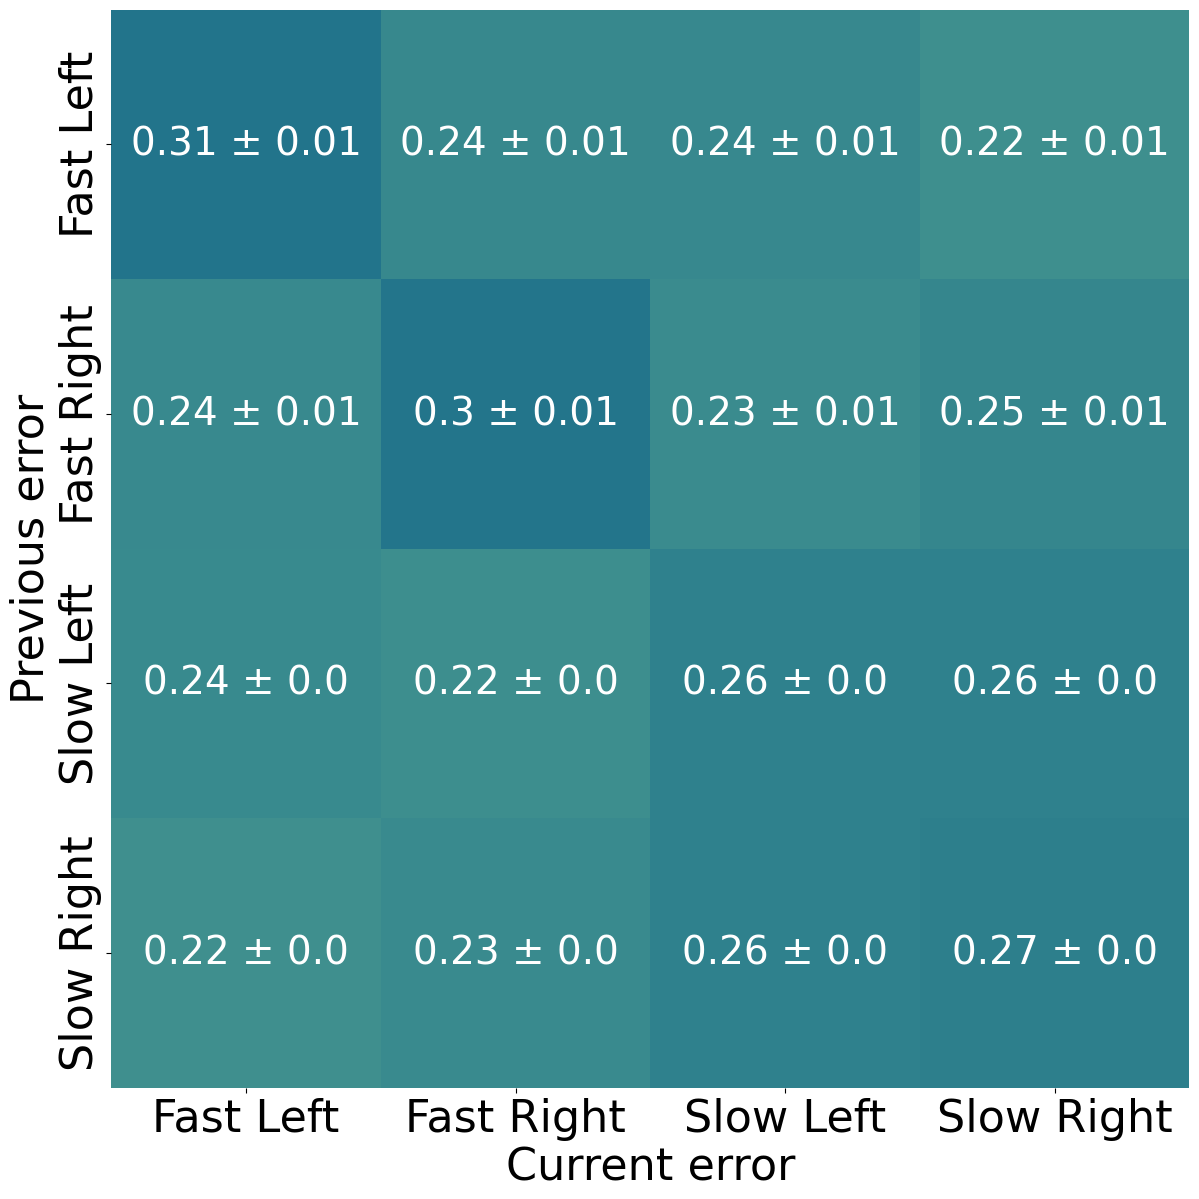

In [14]:
mean_sd_subjects_autocorrelated = (
    simulated_repetition_autocorrelated_all_datasets.groupby(["condition", "prev_condition"])["cond_prop"]
      .agg(["mean", "std"])
      .reset_index()
)

# Put in matrix form
prop_table_mean = mean_sd_subjects_autocorrelated.pivot(index="prev_condition", columns="condition", values="mean")
prop_table_std  = mean_sd_subjects_autocorrelated.pivot(index="prev_condition", columns="condition", values="std")

annot = prop_table_mean.round(2).astype(str) + " ± " + (prop_table_std/np.sqrt(len(np.unique(simulated_repetition_autocorrelated_all_datasets['subj'])))).round(2).astype(str)
condition_labels = ['Fast Left', 'Fast Right', 'Slow Left', 'Slow Right']

plt.figure(figsize=(14,14))
ax = sns.heatmap(
    prop_table_mean,
    annot=annot,
    fmt="",
    cmap="crest",
    vmin = 0.0,
    vmax = 0.5,
    #cbar_kws={'label': 'Mean proportion'},
    xticklabels=condition_labels,
    yticklabels=condition_labels,
    square=True,
    cbar=False
)


ax.tick_params(axis='x', labelsize=fontsize_heatmap)
ax.tick_params(axis='y', labelsize=fontsize_heatmap)

for text in ax.texts:
    text.set_fontsize(28)

plt.ylabel("Previous error", fontsize=fontsize_heatmap)
plt.xlabel("Current error", fontsize=fontsize_heatmap)

plt.savefig("autocorrelated_predicted_repetition_matrix.png", dpi=300, transparent=True)

### Correlating the empirical and predicted conditional accuracy function

In [26]:
correlation_caf = []

empirical_caf_all_datasets = []
simulated_caf_vanilla_all_datasets = []
simulated_caf_variability_all_datasets = []
simulated_caf_autocorrelated_all_datasets = []


for dataset in datasets:
    
    # Import caf 
    empirical_caf = pd.read_csv(f"/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/3. Autocorrelated DDM/Data/{dataset}_autocorrelated_ddm_empirical_caf_subject.csv")

    simulated_caf_vanilla = pd.read_csv(f"/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/1. Vanilla DDM/Data/{dataset}_vanilla_ddm_predicted_caf_subject.csv")
    simulated_caf_variability = pd.read_csv(f"/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/2. Across-trial variability DDM/Data/{dataset}_across_trial_variability_ddm_predicted_caf_subject.csv")
    simulated_caf_autocorrelated = pd.read_csv(f"/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/3. Autocorrelated DDM/Data/{dataset}_autocorrelated_ddm_predicted_caf_subject.csv")

    # Add dataset_subject
    for df in [
    empirical_caf,
    simulated_caf_vanilla,
    simulated_caf_variability,
    simulated_caf_autocorrelated]:
        df["dataset_subject"] = dataset + "_" + df["subj"].astype(str)

    # Save all of them in one dataset (for plotting later)
    empirical_caf_all_datasets.append(empirical_caf)
    simulated_caf_vanilla_all_datasets.append(simulated_caf_vanilla)
    simulated_caf_variability_all_datasets.append(simulated_caf_variability)
    simulated_caf_autocorrelated_all_datasets.append(simulated_caf_autocorrelated)

    # Get number of subjects
    unique_ids, counts = np.unique(empirical_caf['subj'], return_counts=True)
    num_subjects = len(unique_ids)

    # Correlate empirical and predicted caf 
    correlation_vanilla = []
    correlation_variability = []
    correlation_autocorrelated = []
    
    for subj in range(num_subjects):
        r_vanilla, _        = pearsonr(empirical_caf['mean'][empirical_caf["subj"] == subj],
                                        simulated_caf_vanilla['mean'][simulated_caf_vanilla["subj"] == subj])
        r_variability, _    = pearsonr(empirical_caf['mean'][empirical_caf["subj"] == subj],
                                        simulated_caf_variability['mean'][simulated_caf_variability["subj"] == subj])
        r_autocorrelated, _ = pearsonr(empirical_caf['mean'][empirical_caf["subj"] == subj],
                                        simulated_caf_autocorrelated['mean'][simulated_caf_autocorrelated["subj"] == subj])
        correlation_vanilla.append(r_vanilla)
        correlation_variability.append(r_variability)
        correlation_autocorrelated.append(r_autocorrelated)

    correlation_long = (correlation_vanilla + correlation_variability + correlation_autocorrelated)    
    subject = np.tile(np.arange(num_subjects), 3)
    
    df_long = pd.DataFrame({
        'dataset': dataset,
        'subject': subject,
        'dataset_subject': dataset + "_" + subject.astype(str),
        'correlation': correlation_long,
        'model': np.repeat(['vanilla', 'variability', 'autocorrelated'], num_subjects)
    })

    correlation_caf.append(df_long)

# Combine all datasets into one DataFrame
correlation_caf = pd.concat(correlation_caf, ignore_index=True)

empirical_caf_all_datasets = pd.concat(empirical_caf_all_datasets, ignore_index=True)
simulated_caf_vanilla_all_datasets = pd.concat(simulated_caf_vanilla_all_datasets, ignore_index=True)
simulated_caf_variability_all_datasets = pd.concat(simulated_caf_variability_all_datasets, ignore_index=True)
simulated_caf_autocorrelated_all_datasets = pd.concat(simulated_caf_autocorrelated_all_datasets, ignore_index=True)

In [27]:
correlation_caf.to_csv(
    "/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/4. Correlating repetition matrices/correlation_empirical_predicted_caf.csv",
    index=False
)

### Plot CAF over all datasets

In [33]:
sns.set_theme(style="ticks", context="talk")

fontsize = 14

#### 1. Empirical data

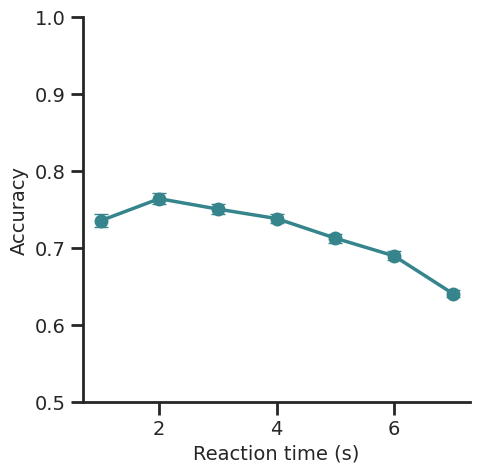

In [34]:
mean_sd_subjects_empirical_caf = (
    empirical_caf_all_datasets.groupby(["quantiles_rt"])["mean"]
      .agg(["mean", "std"])
      .reset_index()
)

fig, ax = plt.subplots(figsize=(5, 5))

ax.errorbar(
    x=mean_sd_subjects_empirical_caf["quantiles_rt"],
    y=mean_sd_subjects_empirical_caf["mean"],
    yerr=mean_sd_subjects_empirical_caf["std"] / np.sqrt(
        len(np.unique(empirical_caf_all_datasets["dataset_subject"]))
    ),
    fmt='o-',
    linewidth=2.5,
    capsize=5,
    color='#36848C'
)

ax.set_xlabel("Reaction time (s)", fontsize=fontsize)
ax.set_ylabel("Accuracy", fontsize=fontsize)
ax.set_ylim(0.5, 1.0)
ax.tick_params(labelsize=fontsize)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(2.0)

sns.despine(ax=ax)
ax.tick_params(width=2.0)

plt.savefig("empirical_caf.png", dpi=300, transparent=True)

#### 2. Vanilla DDM

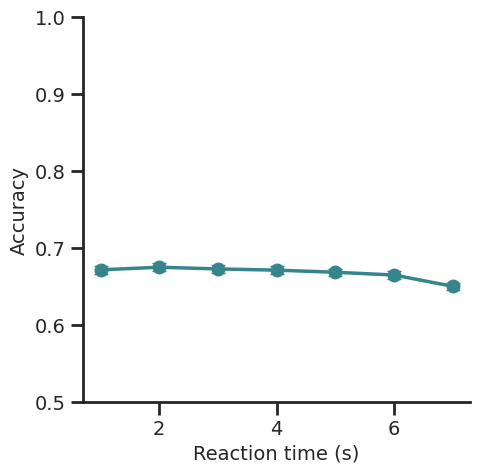

In [35]:
mean_sd_subjects_vanilla_caf = (
    simulated_caf_vanilla_all_datasets.groupby(["quantiles_rt"])["mean"]
      .agg(["mean", "std"])
      .reset_index()
)

fig, ax = plt.subplots(figsize=(5, 5))

ax.errorbar(
    x=mean_sd_subjects_vanilla_caf["quantiles_rt"],
    y=mean_sd_subjects_vanilla_caf["mean"],
    yerr=mean_sd_subjects_vanilla_caf["std"] / np.sqrt(
        len(np.unique(simulated_caf_vanilla_all_datasets["dataset_subject"]))
    ),
    fmt='o-',
    linewidth=2.5,
    capsize=5,
    color='#36848C'
)

ax.set_xlabel("Reaction time (s)", fontsize=fontsize)
ax.set_ylabel("Accuracy", fontsize=fontsize)
ax.set_ylim(0.5, 1.0)
ax.tick_params(labelsize=fontsize)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(2.0)

sns.despine(ax=ax)
ax.tick_params(width=2.0)

plt.savefig("vanilla_caf.png", dpi=300, transparent=True)

#### 3. Across-trial variability DDM

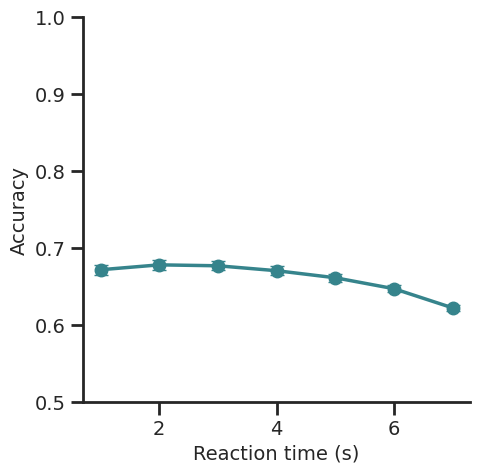

In [36]:
mean_sd_subjects_variability_caf = (
    simulated_caf_variability_all_datasets.groupby(["quantiles_rt"])["mean"]
      .agg(["mean", "std"])
      .reset_index()
)

fig, ax = plt.subplots(figsize=(5, 5))

ax.errorbar(
    x=mean_sd_subjects_variability_caf["quantiles_rt"],
    y=mean_sd_subjects_variability_caf["mean"],
    yerr=mean_sd_subjects_variability_caf["std"] / np.sqrt(
        len(np.unique(simulated_caf_variability_all_datasets["dataset_subject"]))
    ),
    fmt='o-',
    linewidth=2.5,
    capsize=5,
    color='#36848C'
)

ax.set_xlabel("Reaction time (s)", fontsize=fontsize)
ax.set_ylabel("Accuracy", fontsize=fontsize)
ax.set_ylim(0.5, 1.0)
ax.tick_params(labelsize=fontsize)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(2.0)

sns.despine(ax=ax)
ax.tick_params(width=2.0)

plt.savefig("variability_caf.png", dpi=300, transparent=True)

#### 4. Autocorrelated DDM

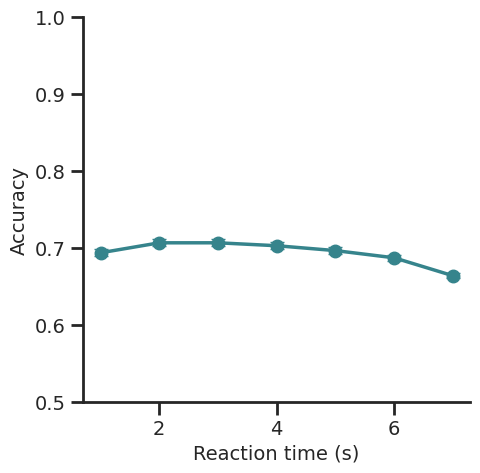

In [37]:
mean_sd_subjects_autocorrelated_caf = (
    simulated_caf_autocorrelated_all_datasets.groupby(["quantiles_rt"])["mean"]
      .agg(["mean", "std"])
      .reset_index()
)

fig, ax = plt.subplots(figsize=(5, 5))

ax.errorbar(
    x=mean_sd_subjects_autocorrelated_caf["quantiles_rt"],
    y=mean_sd_subjects_autocorrelated_caf["mean"],
    yerr=mean_sd_subjects_autocorrelated_caf["std"] / np.sqrt(
        len(np.unique(simulated_caf_autocorrelated_all_datasets["dataset_subject"]))
    ),
    fmt='o-',
    linewidth=2.5,
    capsize=5,
    color='#36848C'
)

ax.set_xlabel("Reaction time (s)", fontsize=fontsize)
ax.set_ylabel("Accuracy", fontsize=fontsize)
ax.set_ylim(0.5, 1.0)
ax.tick_params(labelsize=fontsize)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(2.0)

sns.despine(ax=ax)
ax.tick_params(width=2.0)

plt.savefig("autocorrelated_caf.png", dpi=300, transparent=True)